In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

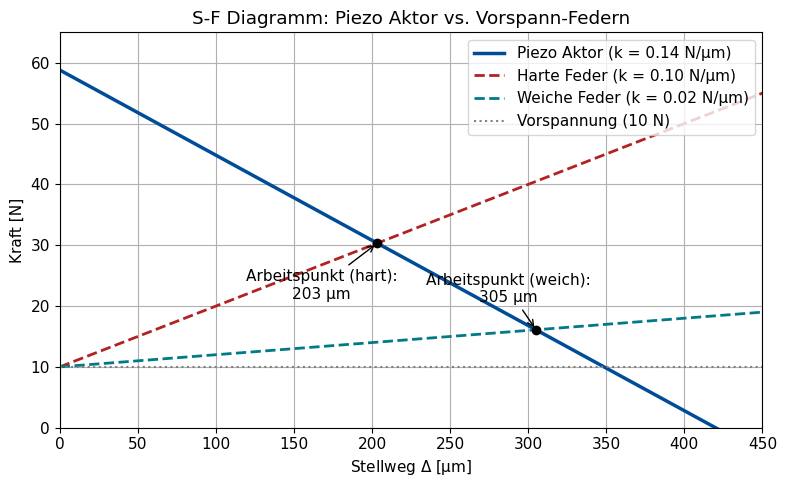

In [2]:
# ==========================================
# 1. Parameter für den Piezo und die Federn
# ==========================================
S_max = 420.0          # Maximaler Leerlauf-Hub des Piezos [µm]
k_piezo = 0.14         # Steifigkeit des Piezos [N/µm] (vgl. PI-Modell)
F_block = k_piezo * S_max  # Berechnete Blockierkraft [N] (ca. 58.8 N)

F_preload = 10.0       # Initiale Vorspannung der Feder [N] (Spielfreiheit!)

# Feder 1: Zu hart (z.B. dicker Stahl)
k_feder_hart = 0.10    # [N/µm]

# Feder 2: Optimal / Weich (z.B. dünne Blattfeder / Flexure)
k_feder_weich = 0.02   # [N/µm]

# ==========================================
# 2. Berechnungen
# ==========================================
# Stellweg-Achse (0 bis 450 µm)
x = np.linspace(0, 450, 500)

# Kraft-Weg-Gerade des Piezos (fällt ab)
F_piezo = F_block - k_piezo * x

# Kraft-Weg-Geraden der Federn (steigen an)
F_hart = F_preload + k_feder_hart * x
F_weich = F_preload + k_feder_weich * x

# Schnittpunkte (Arbeitspunkte) berechnen:
# Gleichsetzen: F_block - k_p * x = F_preload + k_f * x
x_schnitt_hart = (F_block - F_preload) / (k_piezo + k_feder_hart)
F_schnitt_hart = F_preload + k_feder_hart * x_schnitt_hart

x_schnitt_weich = (F_block - F_preload) / (k_piezo + k_feder_weich)
F_schnitt_weich = F_preload + k_feder_weich * x_schnitt_weich

# ==========================================
# 3. Plotting
# ==========================================
plt.figure(figsize=(8, 5))
plt.rcParams.update({"font.size": 11, "axes.grid": True})

# Piezo-Kennlinie
plt.plot(x, F_piezo, color='#004C97', linewidth=2.5, label='Piezo Aktor (k = 0.14 N/µm)')

# Feder-Kennlinien
plt.plot(x, F_hart, color='#B22222', linestyle='--', linewidth=2, label='Harte Feder (k = 0.10 N/µm)')
plt.plot(x, F_weich, color='#007A87', linestyle='--', linewidth=2, label='Weiche Feder (k = 0.02 N/µm)')

# Arbeitspunkte markieren
plt.plot(x_schnitt_hart, F_schnitt_hart, 'ko', markersize=6)
plt.annotate(f'Arbeitspunkt (hart):\n{x_schnitt_hart:.0f} µm', 
             (x_schnitt_hart, F_schnitt_hart), textcoords="offset points", xytext=(-40, -40), ha='center',
             arrowprops=dict(arrowstyle="->", color='black'))

plt.plot(x_schnitt_weich, F_schnitt_weich, 'ko', markersize=6)
plt.annotate(f'Arbeitspunkt (weich):\n{x_schnitt_weich:.0f} µm', 
             (x_schnitt_weich, F_schnitt_weich), textcoords="offset points", xytext=(-20, 20), ha='center',
             arrowprops=dict(arrowstyle="->", color='black'))

# Vorspannung markieren
plt.axhline(F_preload, color='gray', linestyle=':', label='Vorspannung (10 N)')

# Achsen begrenzen und beschriften
plt.xlim(0, 450)
plt.ylim(0, 65)
plt.xlabel("Stellweg $\Delta$ [µm]")
plt.ylabel("Kraft [N]")
plt.title("S-F Diagramm: Piezo Aktor vs. Vorspann-Federn")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

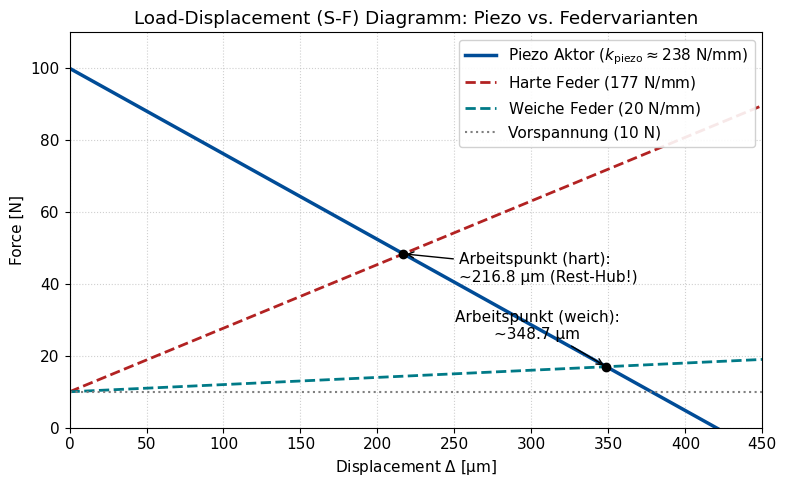

In [ ]:
# ==========================================
# 1. Parameter für Piezo & Harte Feder
# ==========================================
S_max = 420.0          # Maximaler Hub des Thorlabs PK2FVF1 [µm]
F_block = 100.0        # Effektive Blockierkraft [N]
k_piezo = F_block / S_max  # Steifigkeit des Piezos (~0.238 N/µm = 238 N/mm)

F_preload = 10.0       # Vorspannung [N]

# Die harte Feder aus der Dynamik-Berechnung: 177 N/mm = 0.177 N/µm
k_hard = 177.0 / 1000.0  

# Zum Vergleich eine weiche Feder: 20 N/mm = 0.02 N/µm
k_soft = 20.0 / 1000.0   

# ==========================================
# 2. Berechnungen
# ==========================================
x = np.linspace(0, 450, 500)

# Kennlinien
F_piezo = F_block - k_piezo * x
F_hard_spring = F_preload + k_hard * x
F_soft_spring = F_preload + k_soft * x

# Schnittpunkt (Harte Feder)
x_hard = (F_block - F_preload) / (k_piezo + k_hard)
F_hard = F_preload + k_hard * x_hard

# Schnittpunkt (Weiche Feder)
x_soft = (F_block - F_preload) / (k_piezo + k_soft)
F_soft = F_preload + k_soft * x_soft

# ==========================================
# 3. Plotting (Thesis-Ready)
# ==========================================
plt.figure(figsize=(8, 5))
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.6})

# Linien zeichnen
plt.plot(x, F_piezo, color='#004C97', linewidth=2.5, label=r'Piezo Aktor ($k_\text{piezo} \approx 238\text{ N/mm}$)')
plt.plot(x, F_hard_spring, color='#B22222', linestyle='--', linewidth=2, label=r'Harte Feder ($177\text{ N/mm}$)')
plt.plot(x, F_soft_spring, color='#007A87', linestyle='--', linewidth=2, label=r'Weiche Feder ($20\text{ N/mm}$)')

# Arbeitspunkte markieren
plt.plot(x_hard, F_hard, 'ko', markersize=6)
plt.annotate(f'Arbeitspunkt (hart):\n~{x_hard:.1f} µm (Rest-Hub!)', 
             (x_hard, F_hard), textcoords="offset points", xytext=(40, -20), ha='left',
             arrowprops=dict(arrowstyle="->", color='black', lw=1))

plt.plot(x_soft, F_soft, 'ko', markersize=6)
plt.annotate(f'Arbeitspunkt (weich):\n~{x_soft:.1f} µm', 
             (x_soft, F_soft), textcoords="offset points", xytext=(-50, 20), ha='center',
             arrowprops=dict(arrowstyle="->", color='black', lw=1))

plt.axhline(F_preload, color='gray', linestyle=':', label='Vorspannung (10 N)')

# Layout
plt.xlim(0, 450)
plt.ylim(0, 110)
plt.xlabel(r"Displacement $\Delta$ [µm]")
plt.ylabel(r"Force [N]")
plt.title("Load-Displacement (S-F) Diagramm: Piezo vs. Federvarianten")
plt.legend(loc="upper right", framealpha=0.9)

plt.tight_layout()
# plt.savefig("sf_diagram_comparison.pdf")
plt.show()

interact(
    mass_in_g,
    l_mm=FloatSlider(
        value=50,
        min=10,
        max=200,
        step=1,
        description="m (g)"
    )
)

In [5]:
# ==========================================
# 1. Parameter für Piezo & Federn
# ==========================================
S_max = 420.0          # Maximaler Hub des Thorlabs PK2FVF1 [µm]
F_block = 100.0        # Effektive Blockierkraft [N]
k_piezo = F_block / S_max  # Steifigkeit des Piezos (~0.238 N/µm = 238 N/mm)

F_preload = 10.0       # Vorspannung [N]
target_f0 = 300.0      # Ziel-Eigenfrequenz für die Dynamik [Hz]

# ==========================================
# 2. Interaktive Funktion für das Widget
# ==========================================
def plot_sf_interactive(l_mm):
    # l_mm entspricht hier dem Wert vom Slider (Masse in g)
    mass_kg = l_mm / 1000.0
    
    # Erforderliche Federsteifigkeit k aus Masse und Ziel-Eigenfrequenz berechnen:
    # f0 = 1/(2*pi) * sqrt(k_total / m) => k_total_N_m = (2*pi*f0)^2 * m
    k_total_N_m = (2 * np.pi * target_f0)**2 * mass_kg
    k_dyn = k_total_N_m / 1000.0  # Umrechnung in N/µm (= N/mm)

    # Berechnungen
    x = np.linspace(0, 450, 500)
    F_piezo = F_block - k_piezo * x
    F_dyn_spring = F_preload + k_dyn * x

    # Schnittpunkt (Dynamische Feder)
    x_dyn = (F_block - F_preload) / (k_piezo + k_dyn)
    F_dyn = F_preload + k_dyn * x_dyn

    # Zum Vergleich noch die feste harte Feder aus der vorherigen Berechnung
    k_hard = 177.0 / 1000.0
    x_hard = (F_block - F_preload) / (k_piezo + k_hard)
    F_hard = F_preload + k_hard * x_hard
    F_hard_spring = F_preload + k_hard * x

    # ==========================================
    # 3. Plotting (Thesis-Ready)
    # ==========================================
    plt.figure(figsize=(8, 5))
    plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.6})

    # Linien zeichnen
    plt.plot(x, F_piezo, color='#004C97', linewidth=2.5, label=r'Piezo Aktor ($k_\text{piezo} \approx 238\text{ N/mm}$)')
    plt.plot(x, F_hard_spring, color='#B22222', linestyle=':', linewidth=1.5, label=r'Harte Feder fix ($177\text{ N/mm}$)')
    plt.plot(x, F_dyn_spring, color='#007A87', linestyle='--', linewidth=2, label=r'Dynamische Feder ($k$=' + f'{k_dyn*1000:.1f} N/mm)')

    # Arbeitspunkte markieren
    plt.plot(x_dyn, F_dyn, 'ko', markersize=6)
    plt.annotate(f'Arbeitspunkt (dyn):\n~{x_dyn:.1f} µm (Masse: {l_mm:.0f} g)', 
                 (x_dyn, F_dyn), textcoords="offset points", xytext=(-50, 20), ha='center',
                 arrowprops=dict(arrowstyle="->", color='black', lw=1))

    plt.axhline(F_preload, color='gray', linestyle=':', label='Vorspannung (10 N)')

    # Layout
    plt.xlim(0, 450)
    plt.ylim(0, 110)
    plt.xlabel(r"Displacement $\Delta$ [µm]")
    plt.ylabel(r"Force [N]")
    plt.title(f"S-F Diagramm: Piezo vs. Dynamische Feder ($f_0$ = {target_f0:.0f} Hz)")
    plt.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Interaktives Widget starten
# ==========================================
interact(
    plot_sf_interactive,
    l_mm=FloatSlider(
        value=50,
        min=5,
        max=200,
        step=1,
        description="Masse [g]",
        style={'description_width': 'initial'}
    )
)

interactive(children=(FloatSlider(value=50.0, description='Masse [g]', max=200.0, min=5.0, step=1.0, style=Sli…

<function __main__.plot_sf_interactive(l_mm)>

In [ ]:
# ==========================================
# 1. Parameter für Piezo & Setup
# ==========================================
S_max = 420.0          # Maximaler Hub des Thorlabs PK2FVF1 [µm]
F_block = 100.0        # Effektive Blockierkraft [N]
k_piezo = F_block / S_max  # Steifigkeit des Piezos (~0.238 N/µm = 238 N/mm)

F_preload = 10.0       # Vorspannung [N]

# ==========================================
# 2. Interaktive Funktion mit zwei Parametern
# ==========================================
def plot_sf_interactive(mass_g, f0_hz):
    mass_kg = mass_g / 1000.0
    
    # Erforderliche Federsteifigkeit k aus Masse und gewählter Eigenfrequenz berechnen:
    # f0 = 1/(2*pi) * sqrt(k_total / m) => k_total_N_m = (2*pi*f0)^2 * m
    k_total_N_m = (2 * np.pi * f0_hz)**2 * mass_kg
    k_dyn = k_total_N_m / 1000.0  # Umrechnung in N/µm (= N/mm)

    # Berechnungen
    x = np.linspace(0, 450, 500)
    F_piezo = F_block - k_piezo * x
    F_dyn_spring = F_preload + k_dyn * x

    # Schnittpunkt (Dynamische Feder)
    x_dyn = (F_block - F_preload) / (k_piezo + k_dyn)
    F_dyn = F_preload + k_dyn * x_dyn

    # ==========================================
    # 3. Plotting (Thesis-Ready)
    # ==========================================
    plt.figure(figsize=(8, 5))
    plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.6})

    # Linien zeichnen (nur Piezo und die eine dynamische Feder)
    plt.plot(x, F_piezo, color='#004C97', linewidth=2.5, label=r'Piezo Aktor ($k_\text{piezo} \approx 238\text{ N/mm}$)')
    plt.plot(x, F_dyn_spring, color='#007A87', linestyle='--', linewidth=2, label=r'Erforderliche Feder ($k$=' + f'{k_dyn*1000:.1f} N/mm)')

    # Arbeitspunkt markieren
    plt.plot(x_dyn, F_dyn, 'ko', markersize=6)
    plt.annotate(f'Arbeitspunkt:\n~{x_dyn:.1f} µm (Rest-Hub)', 
                 (x_dyn, F_dyn), textcoords="offset points", xytext=(-50, 20), ha='center',
                 arrowprops=dict(arrowstyle="->", color='black', lw=1))

    plt.axhline(F_preload, color='gray', linestyle=':', label='Vorspannung (10 N)')

    # Layout
    plt.xlim(0, 450)
    plt.ylim(0, 110)
    plt.xlabel(r"Displacement $\Delta$ [µm]")
    plt.ylabel(r"Force [N]")
    plt.title(f"S-F Diagramm: Dynamische Auslegung ($f_0$ = {f0_hz:.0f} Hz, Masse = {mass_g:.0f} g)")
    plt.legend(loc="upper right", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# ==========================================
# 4. Interaktive Widgets starten (Masse & Frequenz)
# ==========================================
interact(
    plot_sf_interactive,
    mass_g=FloatSlider(
        value=50.0,
        min=5.0,
        max=200.0,
        step=1.0,
        description="Masse [g]",
        style={'description_width': 'initial'}
    ),
    f0_hz=FloatSlider(
        value=300.0,
        min=50.0,
        max=1000.0,
        step=10.0,
        description="Ziel-f0 [Hz]",
        style={'description_width': 'initial'}
    )
)

interactive(children=(FloatSlider(value=50.0, description='Masse [g]', max=200.0, min=5.0, step=1.0, style=Sli…

<function __main__.plot_sf_interactive(mass_g, f0_hz)>